In [1]:
import numpy as np
from math import *
import matplotlib.pyplot as plt
import scipy.stats as stats
import scipy

# 6) Les tests (non paramétriques)

Avant de rentrer en détails dans les tests, voyons quelques commentaires sur la méthodologie. Chacun des tests qui va suivre se base sur le calcul d'une certaine statistique $D_n$ dépendant de notre échantillon, dont l'on connait la loi (parfois asymptotiquement) sous $H_0$, et la la zone de rejet d'un test de niveau $\alpha$ sera alors construite de la façon suivante : 
$$R_\alpha = \{ D > s_\alpha \},$$
où $s_\alpha$ est le quantile d'ordre $1 - \alpha$ de la loi de $D_n$ sous $H_0$. 

Une autre façon de construire un test de niveau $\alpha$, c'est d'utiliser la p-valeur. Mais avant de l'utiliser, il faut déjà savoir ce qu'elle représente ! De façon générale (peu importe la tête de la zone de rejet), la p-valeur est le plus petit seuil pour lequel on rejette l'hypothèse $H_0$ avec notre échantillon, autrement dit, 
$$p = \inf \{\alpha \in [0,1], D_n \in R_\alpha \}.$$
Dans le cas d'une zone de rejet de la forme de celles que l'on considère, la p-valeur s'interprète comme la probabilité d'obtenir, sous $H_0$, une valeur de $D_n$ au moins aussi grande que celle que l'on a obtenue. Ainsi, obtenir une p-valeur toute petite incite à rejeter : sous $H_0$, la probabilité d'obtenir une valeur si grande de $D_n$ est toute petite, donc $H_0$ n'est probablement pas vérifiée. 

Pour définir un test de niveau $\alpha$ en utilisant cette p-valeur, on définit la zone de rejet par 
$$R_\alpha = \{ p \le \alpha \}.$$ 
Les deux tests ne sont pas équivalents : si l'on rejette avec le premier, on rejette forcément avec le deuxième, mais il peut arriver de rejeter avec le test fourni par la p-valeur, sans pour autant rejeter avec le test fourni par la statistique. 

## 6.1) Tests du $\chi^2$

Le premier test auquel on s'intéresse est le test d'adéquation à une loi de probabilité. On considère un $n$-échantillon $X_1, \dots, X_n$ à valeurs dans $\{1,\dots,k\}$ de loi $p$, et on veut tester $H_0 : p=p^*$ contre $H_1 : p \neq p^*$. On définit alors la statistique : 
$$ D_n := \sum_{i=1}^k \frac{(N_i(n) - np^*_i)^2}{np^*_i},$$
avec $N_i(n)= \# \{ j \in \{1,\dots,n \}, X_j =i \}$. 
Alors sous l'hypothèse $H_0$, $D_n$ converge en loi vers une loi du $\chi^2$ à $k-1$ degrés de liberté, et sous l'hypothèse $H_1$, $D_n$ tend presque sûrement vers $+\infty$. On définit alors comme zone de rejet $R_\alpha = \{ D > q_{1-\alpha}\}$, où $q_{1-\alpha}$ est le quantile d'ordre $1 -\alpha$ d'une $\chi^2(k-1)$, et on obtient un test de niveau asymptotique $\alpha$. 

Les packages Python nous fournissent aussi la p-valeur du test, et alors on peut aussi utiliser $R_\alpha = \{p \le \alpha\}$ comme zone de rejet. 

Ce test est à la base conçu pour des lois à support fini mais peut s'étendre au cas de lois discrètes sur $\mathbb{N}$ en regroupant des cases. Dans tous les cas, il faut vérifier le critère suivant : $n \times \displaystyle \min_{1 \le i \le k} p^*_i \ge 5$.

In [4]:
# Voyons un exmple pour une loi de Poisson 
l=4
n=500
m=10
alpha=0.05
I=np.arange(m)
Pm=stats.poisson.pmf(I, mu=l)
print([n*Pm>=5]) # on choisit m pour ne pas avoir à regrouper de cases (il faut un vecteur de True)
P_th=np.array(list(Pm)+[1-np.sum(Pm)]) # on regroupe après m

X=stats.poisson.rvs(mu=l,size=n) 
I2=np.arange(max(X)+1)
F=np.array([np.mean(X==i) for i in I2])
P_emp=np.array(list(F[:m])+[np.sum(F[m:])]) # on regroupe après m également

D,p=stats.chisquare(n*P_emp,n*P_th)

#Avec la statistique D : 
s=stats.chi2.ppf(q=1-alpha, df=len(I)-1)
if D>s:
    print("On rejette H0")
else:
    print("On ne rejette pas H0")

#Avec la p-valeur p : 
print(p)
if p<=alpha:
    print("On rejette H0")
else:
    print("On ne rejette pas H0")

[array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True])]
On ne rejette pas H0
0.6745715955985379
On ne rejette pas H0


Le deuxième test auquel on s'intéresse est le test d'adéquation à une famille de lois. On veut cette fois tester $H_0 : p\in \{p(\theta), \theta \in \Theta\}$ contre $H_1 : p\notin \{p(\theta), \theta \in \Theta\}$, avec $\Theta \subset \mathbb{R}^d$. On définit alors la statistique : 
$$ D_n := \sum_{i=1}^k \frac{(N_i(n) - np_i(\widehat{\theta_n}))^2}{ np_i(\widehat{\theta_n})},$$
où $\widehat{\theta_n}$ est l'estimateur du max de vraisemblance de $\theta$. 
Alors sous l'hypothèse $H_0$, $D_n$ converge en loi vers une loi du $\chi^2$ à $k-d-1$ degrés de liberté, et sous l'hypothèse $H_1$, $D_n$ tend presque sûrement vers $+\infty$. On définit alors comme zone de rejet $R_\alpha = \{ D > q_{1-\alpha}\}$, où $q_{1-\alpha}$ est le quantile d'ordre $1 -\alpha$ d'une $\chi^2(k-d-1)$, et on obtient un test de niveau asymptotique $\alpha$. 

Concrètement, il suffit d'utiliser le test précédent, en faisant un test d'adéquation à une loi, celle dont le paramètre est donné par le max de vraisemblance. 

In [5]:
l=4
n=500
alpha=0.05

X=stats.poisson.rvs(mu=l,size=n)
l_hat = np.mean(X)
print(l_hat)

m=10
I=np.arange(m)
Pm=stats.poisson.pmf(I, mu=l_hat)
print([n*Pm>=5]) # on choisit m pour ne pas avoir à regrouper de cases (il faut un vecteur de True)
P_th=np.array(list(Pm)+[1-np.sum(Pm)]) # on regroupe après m également

 
I2=np.arange(max(X)+1)
F=np.array([np.mean(X==i) for i in I2])
P_emp=np.array(list(F[:m])+[np.sum(F[m:])]) # on regroupe après m

D,p=stats.chisquare(n*P_emp,n*P_th)

#Avec la statistique D : 
s=stats.chi2.ppf(q=1-alpha, df=len(I)-2) # attention à bien faire -d ici, où d est la dimension de l'espace du paramètre, ici 1 
if D>s:
    print("On rejette H0")
else:
    print("On ne rejette pas H0")

#Avec la p-valeur p : 
print(p)
if p<=alpha:
    print("On rejette H0")
else:
    print("On ne rejette pas H0")

4.036
[array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True])]
On ne rejette pas H0
0.9076023364613007
On ne rejette pas H0


Cette fois, on va s'intéresser à un test d'indépendance, donc le cadre change. On considère désormais un échantillon $(Z_1, \dots, Z_n)=((X_1,Y_1), \dots, (X_n,Y_n))$ de copies indépendantes d'un couple $(X,Y)$ à valeurs dans $\{1,\dots,r\} \times \{1,\dots,s\}$, et on cherche à tester $H_0$ : "$X$ et $Y$ sont indépendantes" contre $H_1$ : "$X$ et $Y$ ne sont pas indépendantes". On considère alors la statistique : 
$$D_n := \sum_{i=1}^r \sum_{j=1}^s \frac{\left ( N_{i,j} - \frac{N_{i,.} N_{.,j}}{n} \right)^2}{ \frac{N_{i,.} N_{.,j}}{n}},$$
où $N_{i,j}= \# \{ k \in \{1, \dots, n\}, X_k= i , Y_k=j\}$, $\displaystyle N_{i,.}= \sum_{j=1}^s N_{i,j}$ et $\displaystyle N_{.,j}= \sum_{i=1}^r N_{i,j}$.
Alors sous l'hypothèse $H_0$, $D_n$ converge en loi vers une loi du $\chi^2$ à $(r-1)(s-1)$ degrés de liberté, et sous l'hypothèse $H_1$, $D_n$ tend presque sûrement vers $+\infty$. On définit alors comme zone de rejet $R_\alpha = \{ D > q_{1-\alpha}\}$, où $q_{1-\alpha}$ est le quantile d'ordre $1 -\alpha$ d'une $\chi^2((r-1)(s-1))$, et on obtient un test de niveau asymptotique $\alpha$. 

In [6]:
n=50
r=4
s=4
alpha=0.05

L=stats.randint.rvs(low=0,high=4,size=(n,2))
F=np.zeros((r,s)) # F va être la matrice des 
for i in range(n):
    (x,y)=L[i]
    F[x,y]+=1

D, p_valeur, dlib, expected=stats.chi2_contingency(F)

#Avec la statistique D : 
s=stats.chi2.ppf(q=1-alpha,df=(r-1)*(s-1))
if D>s:
    print("On rejette H0")
else:
    print("On ne rejette pas H0")

#Avec la p-valeur p : 
print(p)
if p<=alpha:
    print("On rejette H0")
else:
    print("On ne rejette pas H0")

On ne rejette pas H0
0.9076023364613007
On ne rejette pas H0


Le dernier test qui nous intéresse est un test d'homogénéité. Le cadre change de nouveau : cette fois, on dispose de $l$ échantillons $E_1, \dots, E_l$ à valeurs dans $\{1,\dots,k\}$ et on veut tester $H_0 :$ "les échantillons sont tous de même loi" contre $H_1$ le complémentaire de $H_0$. On définit la statistique : 
$$D_n := \sum_{i=1}^k \sum_{j=1}^l \frac{\left ( O_{i,j} - \frac{O_{i,.}O_{.,j}}{n}\right)^2 }{\frac{O_{i,.}O_{.,j}}{n}},$$
où $O_{i,j} = \# \{x \in E_j, x=i\}$, $O_{i,.}= \displaystyle \sum_{j=1}^l O_{i,j}$, $O_{.,j}= \displaystyle \sum_{i=1}^k O_{i,j}$ et $ n = \displaystyle \sum_{j=1}^l O_{.,j}$. Alors sous l'hypothèse $H_0$, $D_n$ converge en loi vers une loi du $\chi^2$ à $(k-1)(l-1)$ degrés de liberté, et sous l'hypothèse $H_1$, $D_n$ tend presque sûrement vers $+\infty$. On définit alors comme zone de rejet $R_\alpha = \{ D > q_{1-\alpha}\}$, où $q_{1-\alpha}$ est le quantile d'ordre $1 -\alpha$ d'une $\chi^2((k-1)(l-1))$, et on obtient un test de niveau asymptotique $\alpha$. 

In [8]:
alpha=0.05
k=10
l=3
E1= stats.randint.rvs(low=0, high=10, size=200)
E2= stats.randint.rvs(low=0, high=10, size=200)
E3= stats.randint.rvs(low=0, high=10, size=200)

D,p_value=scipy.stats.friedmanchisquare(E1,E2,E3)

#Avec la statistique D : 
s=stats.chi2.ppf(q=1-alpha,df=(k-1)*(l-1))
if D>s:
    print("On rejette H0")
else:
    print("On ne rejette pas H0")

#Avec la p-valeur p : 
print(p_value)
if p_value<alpha:
    print("On rejette H0")
else:
    print("On ne rejette pas H0")

# sans surprise, on ne rejette pas !

On ne rejette pas H0
0.547189025264087
On ne rejette pas H0


## 6.2) Tests de Kolmogorov-Smirnov

Voyons maintenant le test de Kolmogorov-Smirnov. Selon moi, ce test est LE PLUS IMPORTANT A CONNAITRE. Celui-ci est utilisé pour des lois ayant une fonction de répartitmion continue, et un cadre récurrent où il peut servir, c'est l'illustration de TCL, nous verrons ça dans la partie suivante. 

Le test de K.S. le plus important à connaître, c'est le test d'adéquation à une loi. On considère un $n$-échantillon $X_1, \dots, X_n$ de loi $p$, et on veut tester $H_0 : p=p^*$ contre $H_1 : p \neq p^*$. On suppose que $p$ et $p^*$ sont deux lois dont les fdr sont continues. (ATTENTION, cette condition est restrictive !!) On note $F$ la fonction de répartition de la loi $p^*$, et $F_n$ la fonction de répartition empirique de l'échantillon définie par :
$$ F_n(t) = \frac{1}{n} \sum_{i=1}^n 1_{X_i \le t}.$$
L'idée est de regarder la variable suivante : 
$$ \Vert F_n - F \Vert_\infty. $$
En fait, il y a deux versions du test de KS : une non aysmptotique et une non asymptotique. 

### 1) Test non asymptotique 

En utilisant le fait que $F$ est continue et croissante, et que $F_n$ est continue par morceaux, avec des sauts en les $X_{i}$, on peut écrire : 
$$D_n:= \Vert F_n - F \Vert_\infty = \max_{1 \le i \le n} \max \left ( \left | \frac {i}{n} - F(X_{(i)}) \right | , \left| \frac {i-1}{n} - F(X_{(i)}) \right | \right ), $$
où $(X_{(1)}, \dots, X_{(n)})$ est l'échantillon trié. (Le graphique à venir sert à se convaincre de cette expression.)

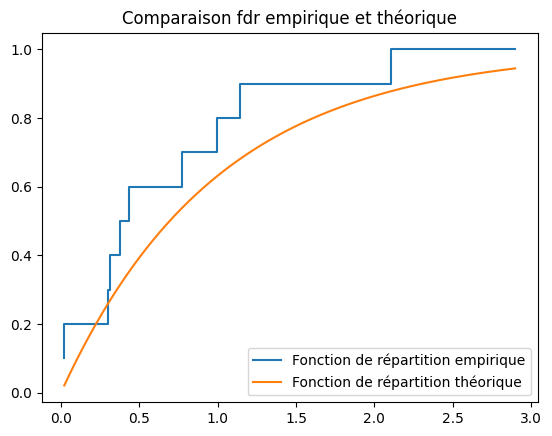

In [12]:
N=10
E=stats.expon.rvs(size=N) # par défaut, scale=1
E=np.sort(E)
F_emp=np.arange(1,N+1)/N
plt.plot(E,F_emp,drawstyle='steps-pre',label='Fonction de répartition empirique')    

X=np.linspace(min(E),max(E),500)
F_th=stats.expon.cdf(X) # par défaut, la loi normale est la centrée réduite 
plt.plot(X,F_th,label='Fonction de répartition théorique')
plt.title('Comparaison fdr empirique et théorique')
plt.legend()
plt.show()

D'une part, cette expression permet de calculer cette statistique, et d'autre part, cela permet de montrer que sous l'hypothèse nulle, la loi de cette statistique ne dépend pas de $p$. En effet, sous $H_0$, les $F(X_i)$ suivent des lois uniformes sur $[0,1]$, et puisque $F$ est croissante, l'échantillon $(F(X_{(1)}), \dots, F(X_{(n)}))$ suit la même loi qu'un échantillon trié de $(U_{(1)},\dots, U_{(n)})$ de loi uniforme sur $[0,1]$. Finalement, 
$$D_n \overset{\mathcal{L}}{=} \max_{1 \le i \le n} \max \left ( \left | \frac {i}{n} - U_{(i)} \right | , \left| \frac {i-1}{n} - U_{(i)} \right | \right )=: \mathbb{U}_n, $$
et la loi de $\mathbb{U}_n$ ne dépend pas de $p$ ! On dit que la statistique $D_n$ est libre de $p$. On peut (grâce à la méthode de Monte-Carlo) calculer les quantiles de cette loi, et cela permet d'obtenir un test.  On définit comme zone de rejet $R_\alpha = \{ D > q_{1-\alpha}\}$, où $q_{1-\alpha}$ est le quantile d'ordre $1 -\alpha$ de la loi de $\mathbb{U}_n$, et on obtient un test de niveau $\alpha$ (NON ASYMPTOTIQUE !).

### 2) Test asymptotique 

Un autre résultat fournit un autre test, cette fois asymptotique. En effet, si l'on définit cette fois la statistique 
$$D_n := \sqrt n \Vert F_n - F \Vert _\infty,$$
alors sous l'hypothèse $H_0$, $D_n$ converge en loi vers une loi appelée loi de Kolmogorov dont la fdr (évidemment pas à retenir !) est donnée par : 
$$G(t):= \mathbb{P}(K \le t ) = 1 - 2\sum_{k=1}^{+ \infty} (-1)^{k-1} e^{-2k^2t^2},$$
et sous l'hypothèse $H_1$, $D_n$ tend presque sûrement vers $+ \infty$. On définit alors comme zone de rejet $R = \{ D_n > q_{1-\alpha}\}$, où $q_{1-\alpha}=G^{-1}(1-\alpha)$, et on obtient un test de niveau ASYMPTOTIQUE $\alpha$. 

L'avantage du test non asymptotique, c'est qu'il est valide peu importe la taille de l'échantillon. En pratique (sur Python par exemple), c'est le test asymptotique qui prend le relais pour $n>100$. On passe au test asymptotique parce que l'on ne peut pas tabuler la loi de $\mathbb{U}_n$ pour tous les $n$ possibles... 

### 3) Mise en pratique

Dans les faits, on demande à Python de faire le test avec le module consacré, et il fait lui même sa tambouille asymptotique ou non (mais il est bien de savoir expliquer comment ça marche quand même !). 

In [13]:
alpha=0.05
l=2
Y=stats.expon.rvs(scale=1/l, size=1000)
# Mon astuce, c'est de renormaliser les variables pour ne pas avoir à le faire dans le cdf du test 
# Par exemple ici, l'échantillon suit une loi exponentielle de paramètre l, alors l fois l'échantillon suit une exponentielle de paramètre 1 
D, p_valeur=stats.kstest(l*Y, stats.expon.cdf)
print(p_valeur)
if p_valeur<=alpha:
    print("On rejette H0")
else:
    print("On ne rejette pas H0")

0.8742459276075665
On ne rejette pas H0


### 4) Homogénéité et autres

On peut aussi définir un test d'homogénéité de Kolmogorov : supposons que l'on dispose de deux échantillons $(X_1,\dots,X_n)$ et $(Y_1, \dots, Y_m)$ de lois respectives $p_X$ et $p_Y$ dont les fdr sont supposées continues. On souhaite tester $H_0 : p_X = p_Y$ contre $H_1 : p_X \neq p_Y $. On note $F_n$ et $G_m$ leurs fonctions de répartition respectives. On définit la statistique : 
$$D_{n,m}:= \sqrt {\frac{mn}{n+m} } \Vert F_n - G_m \Vert_\infty.$$
Alors sous l'hypothèse $H_0$, $D_{n,m}$ converge en loi vers la loi de Kolmogorov de fdr $G$ (définie précédemment), et sous l'hypothèse $H_1$, $D_n$ tend presque sûrement vers $+ \infty$. On définit alors comme zone de rejet $R_\alpha = \{ D > q_{1-\alpha}\}$, où $q_{1-\alpha}=G^{-1}(1-\alpha)$, et on obtient un test de niveau asymptotique $\alpha$. 

In [15]:
alpha=0.05
E1=stats.expon.rvs(scale=1, size=200)
E2=stats.expon.rvs(scale=1, size=200)

D,p_value=scipy.stats.ks_2samp(E1,E2)
print(p_value)
if p_value<=alpha:
    print("On rejette H0")
else:
    print("On ne rejette pas H0")

0.32811544409418575
On ne rejette pas H0


Comme pour le test du $\chi^2$, il existe aussi des adaptations du test de KS, par exemple pour l'adéquation à une famille de lois, mais il y a quelques subitilités... 

## 6.3) Applications de ces tests (important !) 

En pratique, dans un texte de modé, un bon cadre pour utiliser les tests est l'illustration de théorème limite. C'est joli, et très convainquant, de faire un histogramme ou un tracé de comparaison fdr empirique/théorique, mais faire un test, ça permet de quantifier les choses ! 

Imaginons que l'on veuille illustrer une convergence en loi de la forme 
$$E_n \xrightarrow[n \to \infty]{\mathcal L }  E.$$
Pour cela, on simule un $N$-échantillon de même loi que $E_n$ (même stratégie qu'une illustration avec un histogramme par exemple), puis on fait un test d'adéquation à une loi pour cette échantillon. Si la loi limite est discrète, on utilise plutôt un test du $\chi^2$, et si la loi limite est continue, on utilise plutôt le test de KS. 

L'exemple TYPIQUE où c'est génial d'utiliser un test, c'est l'illustration d'un TCL. Pour peu que vous savez expliquer comment marcher le test de KS pendant les questions, vous allez passer pour une personne SUPER savante sans trop de difficultés.

Par exemple, on veut illustrer le TCL pour des variables $(X_i)_{i \ge 1}$ exponentielles de paramètre $\lambda$ : 
$$E_n := \sqrt n \left(\lambda\frac{S_n}{n} - 1 \right)\xrightarrow[n \to \infty]{\mathcal L } \mathcal N (0,1). $$
Pour cela, on simule un $N$-échantillon de variables $(E_n^k)_{1 \le k \le N}$, et puis on réalise un test d'adéquation de KS à une loi normale pour cet échantillon. 

In [16]:
alpha=0.05
N=100
n=500
M=stats.expon.rvs(scale=1/l,size=(N,n))
E=np.array([((sqrt(n)/l)*((n/np.sum(M[i]))-l)) for i in range (N)])
D,p_valeur=stats.kstest(E,stats.norm.cdf)
print(p_valeur)
if p_valeur<=alpha:
    print("On rejette H0")
else:
    print("On ne rejette pas H0")
# Tout le monde est convaincu :) 

0.3383697776481859
On ne rejette pas H0


Voyons maintenant un exemple de loi limite discrète avec la loi des évènements rares, qui nous dit que si $(p_n)_{n \ge 1 }$ est une suite telle que $n p_n \xrightarrow[n \to \infty]{} \lambda  > 0, $ alors 
$$ \mathcal B (n,p_n)  \xrightarrow[n \to \infty]{\mathcal L } \mathcal P (\lambda). $$
On simule un $N$-échantillon $(E_n^k)_{1 \le k \le N }$ de variables indépendantes qui suivent toutes une loi $\mathcal B (n,p_n)$ et puis on réalise un test d'adéquation du $\chi ^2$ à une loi de Poisson de paramètre $\lambda$ pour cet échantillon. 

In [17]:
alpha=0.05
N=500
n=500
l=4
E=stats.binom.rvs(n,l/n,size=N) 

m=10
I=np.arange(m)
Pm=stats.poisson.pmf(I, mu=l)
print([N*Pm>=5]) # attention, ici c'est N la taille de l'échantillon 
P_th=np.array(list(Pm)+[1-np.sum(Pm)]) # on regroupe après m 

I2=np.arange(max(E)+1)
F=np.array([np.mean(E==i) for i in I2])
P_emp=np.array(list(F[:m])+[np.sum(F[m:])]) # on regroupe après m également

D,p=stats.chisquare(N*P_emp,N*P_th)

#Avec la statistique D : 
s=stats.chi2.ppf(q=1-alpha, df=len(I)-1)
if D>s:
    print("On rejette H0")
else:
    print("On ne rejette pas H0")

#Avec la p-valeur p : 
print(p)
if p<=alpha:
    print("On rejette H0")
else:
    print("On ne rejette pas H0")

# De nouveau, tout le monde est convaincu :) 

[array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True])]
On ne rejette pas H0
0.44473333948811067
On ne rejette pas H0


Le test du $\chi^2$ est plus fastidieux à cause des histoires de cases à vérifier... Contrairement au test de KS qui ne mange pas de pain une fois que vous avez déjà obtenu un échantillon pour un histogramme/une fonction de répartition empirique !!